# <center> Analysis Notebook
### <center> Project 1 of the *Machine Learning* (CS-433) course at EPFL
*Authors: me (SCIPER)*

*Date: today*

*Course:*

*Contains:*


---
### <center> Imports and Environment setup

In [56]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import implementations as imp
import helpers
import time

# Seed for reporducibility
np.random.seed(13113)

# In case of reloading the implementations module after editing it
import importlib

importlib.reload(imp)

# plotting parameters
plt.rcParams.update(
    {
        # Figure
        "figure.figsize": (9, 6),
        "figure.dpi": 300,
        # Font
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman"],
        "font.size": 14,
        # Titles and labels
        "axes.titlesize": 20,
        "axes.titleweight": "bold",
        "axes.labelsize": 15,
        # Tick labels
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        # Lines and markers
        "lines.linewidth": 2,
        "lines.markersize": 6,
        # Legend
        "legend.fontsize": 15,
        "legend.frameon": True,
        # Grid
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "grid.alpha": 0.5,
        # Axes
        "axes.linewidth": 1.0,
        # Saving figures
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        # Mathematical text
        "mathtext.fontset": "stix",
    }
)

# Colours I liked
COLORS = {
    "blue": "#5F8FAF",
    "orange": "#E6A15C",
    "red": "#D97A7A",
    "green": "#7FB685",
    "purple": "#A58CC2",
}

# data paths
sample_path = "../dataset/sample_submission.csv"
x_test_path = "../dataset/x_test.csv"
x_train_path = "../dataset/x_train.csv"
y_train_path = "../dataset/y_train.csv"

# If this cell doesnt load, check which directory you work in:
# import os
# print(os.getcwd())
# and make sure the path below is correct
data_path = "../dataset"

In [ ]:
# this takes around 1:15 minutes to run on a laptop, so be patient
x_train, x_test, y_train, train_ids, test_ids = helpers.load_csv_data(data_path)

In [14]:
# 1) Identifiants, logistique de l'appel, poids de sondage
COLS_ADMIN = [
    "Id", "SEQNO", "FMONTH", "IDATE", "IMONTH", "IDAY", "IYEAR", "DISPCODE",
    "_PSU", "_STSTR", "_STRWT", "_RAWRAKE", "_WT2RAKE", "_LLCPWT", "_CLLCPWT",
    "_DUALUSE", "_DUALCOR",
    "CTELENUM", "PVTRESD1", "COLGHOUS", "STATERES", "CELLFON3", "CTELNUM1",
    "CELLFON2", "PVTRESD2", "CCLGHOUS", "CSTATE", "LANDLINE", "QSTVER", "QSTLANG",
    "LADULT", "CADULT", "NUMHHOL2", "SXORIENT", "TRNSGNDR", "CPDEMO1", "ARTHDIS2",
    "FLSHTMY2", "IMFVPLAC", "HIVTSTD3", "WHRTST10", "CAREGIV1", "CRGVREL1", "CRGVHRS1",
    "CIMEMLOS", "SXORIENT", "TRNSGNDR", "MSCODE","HLTHPLN1", "ARTHSOCL"
    ]

# 2) Variables redondantes (on garde une seule version par concept)
COLS_REDUNDANT = [
    # IMC -> on garde _BMI5
    "WEIGHT2", "HEIGHT3", "HTIN4", "HTM4", "WTKG3", "_BMI5CAT", "_RFBMI5", "HEIGHT2"
    # Âge -> on garde _AGE80
    "_AGE65YR", "_AGE_G", "_AGEG5YR",
    # Tabac -> on garde _SMOKER3 (+ USENOW3)
    "SMOKE100", "SMOKDAY2", "LASTSMK2", "STOPSMK2", "_RFSMOK3",
    # Alcool -> on garde _DRNKWEK, _RFBING5, _RFDRHV5
    "ALCDAY5", "AVEDRNK2", "DRNK3GE5", "MAXDRNKS", "DRNKANY5", "DROCDY3_",
    # Hypertension / cholestérol -> on garde _RFHYPE5, _RFCHOL, _CHOLCHK
    "BPHIGH4", "TOLDHI2", "BLOODCHO", "CHOLCHK",
    # Activité physique -> on garde _TOTINDA, _PACAT1, PA1MIN_, _PASTRNG
    "EXERANY2", "EXRACT11", "EXEROFT1", "EXERHMM1", "EXRACT21", "EXEROFT2",
    "EXERHMM2", "STRENGTH", "METVL11_", "METVL21_", "ACTIN11_", "ACTIN21_",
    "PADUR1_", "PADUR2_", "PAFREQ1_", "PAFREQ2_", "_MINAC11", "_MINAC21",
    "STRFREQ_", "PAMISS1_", "PAMIN11_", "PAMIN21_", "PAVIG11_", "PAVIG21_",
    "PA1VIGM_", "_PAINDX1", "_PA150R2", "_PA300R2", "_PA30021", "_PAREC1", "_PASTAE1",
    # Fruits / légumes -> on garde _FRUTSUM, _VEGESUM
    "FRUITJU1", "FRUIT1", "FVBEANS", "FVGREEN", "FVORANG", "VEGETAB1",
    "FTJUDA1_", "FRUTDA1_", "BEANDAY_", "GRENDAY_", "ORNGDAY_", "VEGEDA1_",
    "_MISFRTN", "_MISVEGN", "_FRTRESP", "_VEGRESP", "_FRTLT1", "_VEGLT1",
    "_FRT16", "_VEG23", "_FRUITEX", "_VEGETEX",
    # Origine ethnique -> on garde _RACE
    "_PRACE1", "_MRACE1", "_HISPANC", "_RACEG21", "_RACEGR3", "_RACE_G1",
    "_CHISPNC", "_CRACE1", "_CPRACE",
    # Revenu / éducation / santé générale / ménage -> on garde _INCOMG, _EDUCAG, GENHLTH, _CHLDCNT
    "INCOME2", "EDUCA", "_RFHLTH", "CHILDREN", "NUMADULT", "NUMMEN", "NUMWOMEN", "HHADULT",
    # Ceinture, vaccins, VIH, asthme, arthrite -> versions calculées gardées
    "SEATBELT", "_RFSEAT2", "FLUSHOT6", "PNEUVAC3", "HIVTST6", "_CASTHM1", "ASTHMA3", "ASTHNOW", "HAVARTH3",
]

# 3) Colonnes vides à plus de 80 % sur x_train (modules optionnels : diabète,
#    aidants, vision, asthme détaillé, dépistages cancer, dépression...)
COLS_MOSTLY_NAN = [
    "DIABAGE2", "NUMPHON2", "PREGNANT", "PDIABTST", "PREDIAB1", "INSULIN",
    "BLDSUGAR", "FEETCHK2", "DOCTDIAB", "CHKHEMO3", "FEETCHK", "EYEEXAM",
    "DIABEYE", "DIABEDU", "CRGVREL1", "CRGVLNG1", "CRGVHRS1", "CRGVPRB1",
    "CRGVPERS", "CRGVHOUS", "CRGVMST2", "CRGVEXPT", "VIDFCLT2", "VIREDIF3",
    "VIPRFVS2", "VINOCRE2", "VIEYEXM2", "VIINSUR2", "VICTRCT4", "VIGLUMA2",
    "VIMACDG2", "CDHOUSE", "CDASSIST", "CDHELP", "CDSOCIAL", "CDDISCUS",
    "WTCHSALT", "LONGWTCH", "DRADVISE", "ASTHMAGE", "ASATTACK", "ASERVIST",
    "ASDRVIST", "ASRCHKUP", "ASACTLIM", "ASYMPTOM", "ASNOSLEP", "ASTHMED3",
    "ASINHALR", "HAREHAB1", "STREHAB1", "CVDASPRN", "ASPUNSAF", "RLIVPAIN",
    "RDUCHART", "RDUCSTRK", "ARTTODAY", "ARTHWGT", "ARTHEXER", "ARTHEDU",
    "TETANUS", "HPVADVC2", "HPVADSHT", "SHINGLE2", "HADMAM", "HOWLONG",
    "HADPAP2", "LASTPAP2", "HPVTEST", "HPLSTTST", "HADHYST2", "PROFEXAM",
    "LENGEXAM", "BLDSTOOL", "LSTBLDS3", "HADSIGM3", "HADSGCO1", "LASTSIG3",
    "PCPSAAD2", "PCPSADI1", "PCPSARE1", "PSATEST1", "PSATIME", "PCPSARS1",
    "PCPSADE1", "PCDMDECN", "SCNTMNY1", "SCNTMEL1", "SCNTPAID", "SCNTWRK1",
    "SCNTLPAD", "SCNTLWK1", "RCSGENDR", "RCSRLTN2", "CASTHDX2", "CASTHNO2",
    "EMTSUPRT", "LSATISFY", "ADPLEASR", "ADDOWN", "ADSLEEP", "ADENERGY",
    "ADEAT1", "ADFAIL", "ADTHINK", "ADMOVE", "MISTMNT", "ADANXEV",
]

COLS_TO_DROP = COLS_ADMIN + COLS_REDUNDANT + COLS_MOSTLY_NAN

In [15]:
# Load column names
header = np.genfromtxt(x_train_path,delimiter=",",max_rows=1,dtype=str)

# Id was already removed by helpers.load_csv_data()
feature_names = header[1:]
COLS_TO_DROP = COLS_ADMIN + COLS_REDUNDANT + COLS_MOSTLY_NAN
keep_columns = ~np.isin(feature_names, COLS_TO_DROP)

# Apply exactly the same mask to train and test
x_train_cleaned = x_train[:, keep_columns]
x_test_cleaned = x_test[:, keep_columns]

kept_feature_names = feature_names[keep_columns]
removed_feature_names = feature_names[~keep_columns]

print("Original number of columns:", x_train.shape[1])
print("Number removed:", len(removed_feature_names))
print("Number kept:", x_train_cleaned.shape[1])
Ntr = x_train_cleaned.shape[0]
Nte = x_test_cleaned.shape[0]
D = x_train_cleaned.shape[1]

Original number of columns: 321
Number removed: 256
Number kept: 65


In [35]:
js = [4,8,62,63,30, 31]
replace_by = 0
for j in js:
    x_train_cleaned[np.isnan(x_train_cleaned[:, j]), j] = replace_by
    x_test_cleaned[np.isnan(x_test_cleaned[:, j]), j] = replace_by

sport = 55
x_train_cleaned[np.isnan(x_train_cleaned[:, sport]), sport] = np.median(x_train_cleaned[:, sport][~np.isnan(x_train_cleaned[:, sport])])
x_test_cleaned[np.isnan(x_test_cleaned[:, sport]), sport] = np.median(x_train_cleaned[:, sport][~np.isnan(x_train_cleaned[:, sport])])

aids = 64
x_train_cleaned[np.isnan(x_train_cleaned[:, aids]), aids] = 9
x_test_cleaned[np.isnan(x_test_cleaned[:, aids]), aids] = 9

genhealth = 1
x_train_cleaned[np.isnan(x_train_cleaned[:, genhealth]), genhealth] = 7
x_test_cleaned[np.isnan(x_test_cleaned[:, genhealth]), genhealth] = 7

physhealth = 2
x_train_cleaned[np.isnan(x_train_cleaned[:, physhealth]), physhealth] = 77
x_test_cleaned[np.isnan(x_test_cleaned[:, physhealth]), physhealth] = 77

medcost = 6
x_train_cleaned[np.isnan(x_train_cleaned[:, medcost]), medcost] = 7
x_test_cleaned[np.isnan(x_test_cleaned[:, medcost]), medcost] = 7

checkup1 = 7
x_train_cleaned[np.isnan(x_train_cleaned[:, checkup1]), checkup1] = 7
x_test_cleaned[np.isnan(x_test_cleaned[:, checkup1]), checkup1] = 7

chcscncr = 10
x_train_cleaned[np.isnan(x_train_cleaned[:, chcscncr]), chcscncr] = 7
x_test_cleaned[np.isnan(x_test_cleaned[:, chcscncr]), chcscncr] = 7

diabete3 = 15
x_train_cleaned[np.isnan(x_train_cleaned[:, diabete3]), diabete3] = 7
x_test_cleaned[np.isnan(x_test_cleaned[:, diabete3]), diabete3] = 7

veteran3 = 19
x_train_cleaned[np.isnan(x_train_cleaned[:, veteran3]), veteran3] = 7
x_test_cleaned[np.isnan(x_test_cleaned[:, veteran3]), veteran3] = 7

internet =  21
x_train_cleaned[np.isnan(x_train_cleaned[:, internet]), internet] = 7
x_test_cleaned[np.isnan(x_test_cleaned[:, internet]), internet] = 7

Qlacrt = 22
x_train_cleaned[np.isnan(x_train_cleaned[:, Qlacrt]), Qlacrt] = 7
x_test_cleaned[np.isnan(x_test_cleaned[:, Qlacrt]), Qlacrt] = 7

useequip = 23
x_train_cleaned[np.isnan(x_train_cleaned[:, useequip]), useequip] = 2
x_test_cleaned[np.isnan(x_test_cleaned[:, useequip]), useequip] = 2

blind = 24
x_train_cleaned[np.isnan(x_train_cleaned[:, blind]), blind] = 2
x_test_cleaned[np.isnan(x_test_cleaned[:, blind]), blind] = 2

decide = 25 
x_train_cleaned[np.isnan(x_train_cleaned[:, decide]), decide] = 2
x_test_cleaned[np.isnan(x_test_cleaned[:, decide]), decide] = 2

diffwalk = 26
x_train_cleaned[np.isnan(x_train_cleaned[:, diffwalk]), diffwalk] = 7
x_test_cleaned[np.isnan(x_test_cleaned[:, diffwalk]), diffwalk] = 7


diffdres = 27
x_train_cleaned[np.isnan(x_train_cleaned[:, diffdres]), diffdres] = 7
x_test_cleaned[np.isnan(x_test_cleaned[:, diffdres]), diffdres] = 7

diffalon = 28
x_train_cleaned[np.isnan(x_train_cleaned[:, diffalon]), diffalon] = 7
x_test_cleaned[np.isnan(x_test_cleaned[:, diffalon]), diffalon] = 7

_rfchol = 35
x_train_cleaned[np.isnan(x_train_cleaned[:, _rfchol]), _rfchol] = 9
x_test_cleaned[np.isnan(x_test_cleaned[:, _rfchol]), _rfchol] = 9

_drd = 38
x_train_cleaned[np.isnan(x_train_cleaned[:, _drd]), _drd] = 2
x_test_cleaned[np.isnan(x_test_cleaned[:, _drd]), _drd] = 2

bmi = 42
x_train_cleaned[np.isnan(x_train_cleaned[:, bmi]), bmi] = np.median(x_train_cleaned[:, bmi][~np.isnan(x_train_cleaned[:, bmi])])
x_test_cleaned[np.isnan(x_test_cleaned[:, bmi]), bmi] = np.median(x_train_cleaned[:, bmi][~np.isnan(x_train_cleaned[:, bmi])])

fruts = 50
x_train_cleaned[np.isnan(x_train_cleaned[:, fruts]), fruts] = np.median(x_train_cleaned[:, fruts][~np.isnan(x_train_cleaned[:, fruts])])
x_test_cleaned[np.isnan(x_test_cleaned[:, fruts]), fruts] = np.median(x_train_cleaned[:, fruts][~np.isnan(x_train_cleaned[:, fruts])])

_vegesum = 51
x_train_cleaned[np.isnan(x_train_cleaned[:, _vegesum]), _vegesum] = np.median(x_train_cleaned[:, _vegesum][~np.isnan(x_train_cleaned[:, _vegesum])])
x_test_cleaned[np.isnan(x_test_cleaned[:, _vegesum]), _vegesum] = np.median(x_train_cleaned[:, _vegesum][~np.isnan(x_train_cleaned[:, _vegesum])])

_LMTWRK1 = 58
x_train_cleaned[np.isnan(x_train_cleaned[:, _LMTWRK1]), _LMTWRK1] = 9
x_test_cleaned[np.isnan(x_test_cleaned[:, _LMTWRK1]), _LMTWRK1] = 9

_lmtac = 59
x_train_cleaned[np.isnan(x_train_cleaned[:, _lmtac]), _lmtac] = 9
x_test_cleaned[np.isnan(x_test_cleaned[:, _lmtac]), _lmtac] = 9

_lmt = 60
x_train_cleaned[np.isnan(x_train_cleaned[:, _lmt]), _lmt] = 9
x_test_cleaned[np.isnan(x_test_cleaned[:, _lmt]), _lmt] = 9

In [40]:
print("x_train shape:", x_train_cleaned.shape)

nan_per_column = np.isnan(x_train_cleaned).sum(axis=0)

for j, n_nan in enumerate(nan_per_column):
    if n_nan > 0:
        percentage = 100 * n_nan / x_train_cleaned.shape[0]
        print(f"Column {j}: {n_nan} NaNs ({percentage:.2f}%)")
        print(kept_feature_names[j])


print("x_train shape:", x_test_cleaned.shape)

nan_per_column = np.isnan(x_test_cleaned).sum(axis=0)

for j, n_nan in enumerate(nan_per_column):
    if n_nan > 0:
        percentage = 100 * n_nan / x_test_cleaned.shape[0]
        print(f"Column {j}: {n_nan} NaNs ({percentage:.2f}%)")
        print(kept_feature_names[j])

x_train shape: (328135, 65)
x_train shape: (109379, 65)


---
### <center> Data Analysis and Cleaning

In [41]:
print("x_train shape:", x_train_cleaned.shape)
print("x_test shape:", x_test_cleaned.shape)
print("y_train shape:", y_train.shape)

print("x_train dtype:", x_train_cleaned.dtype)
print("y_train dtype:", y_train.dtype)
total_observations = x_train_cleaned.shape[0] + x_test_cleaned.shape[0]

print(
    f"We have a split of {x_train_cleaned.shape[0]/total_observations:.2%} "
    f"for training and {x_test_cleaned.shape[0]/total_observations:.2%} are for "
    f"testing."
)

x_train shape: (328135, 65)
x_test shape: (109379, 65)
y_train shape: (328135,)
x_train dtype: float64
y_train dtype: int64
We have a split of 75.00% for training and 25.00% are for testing.


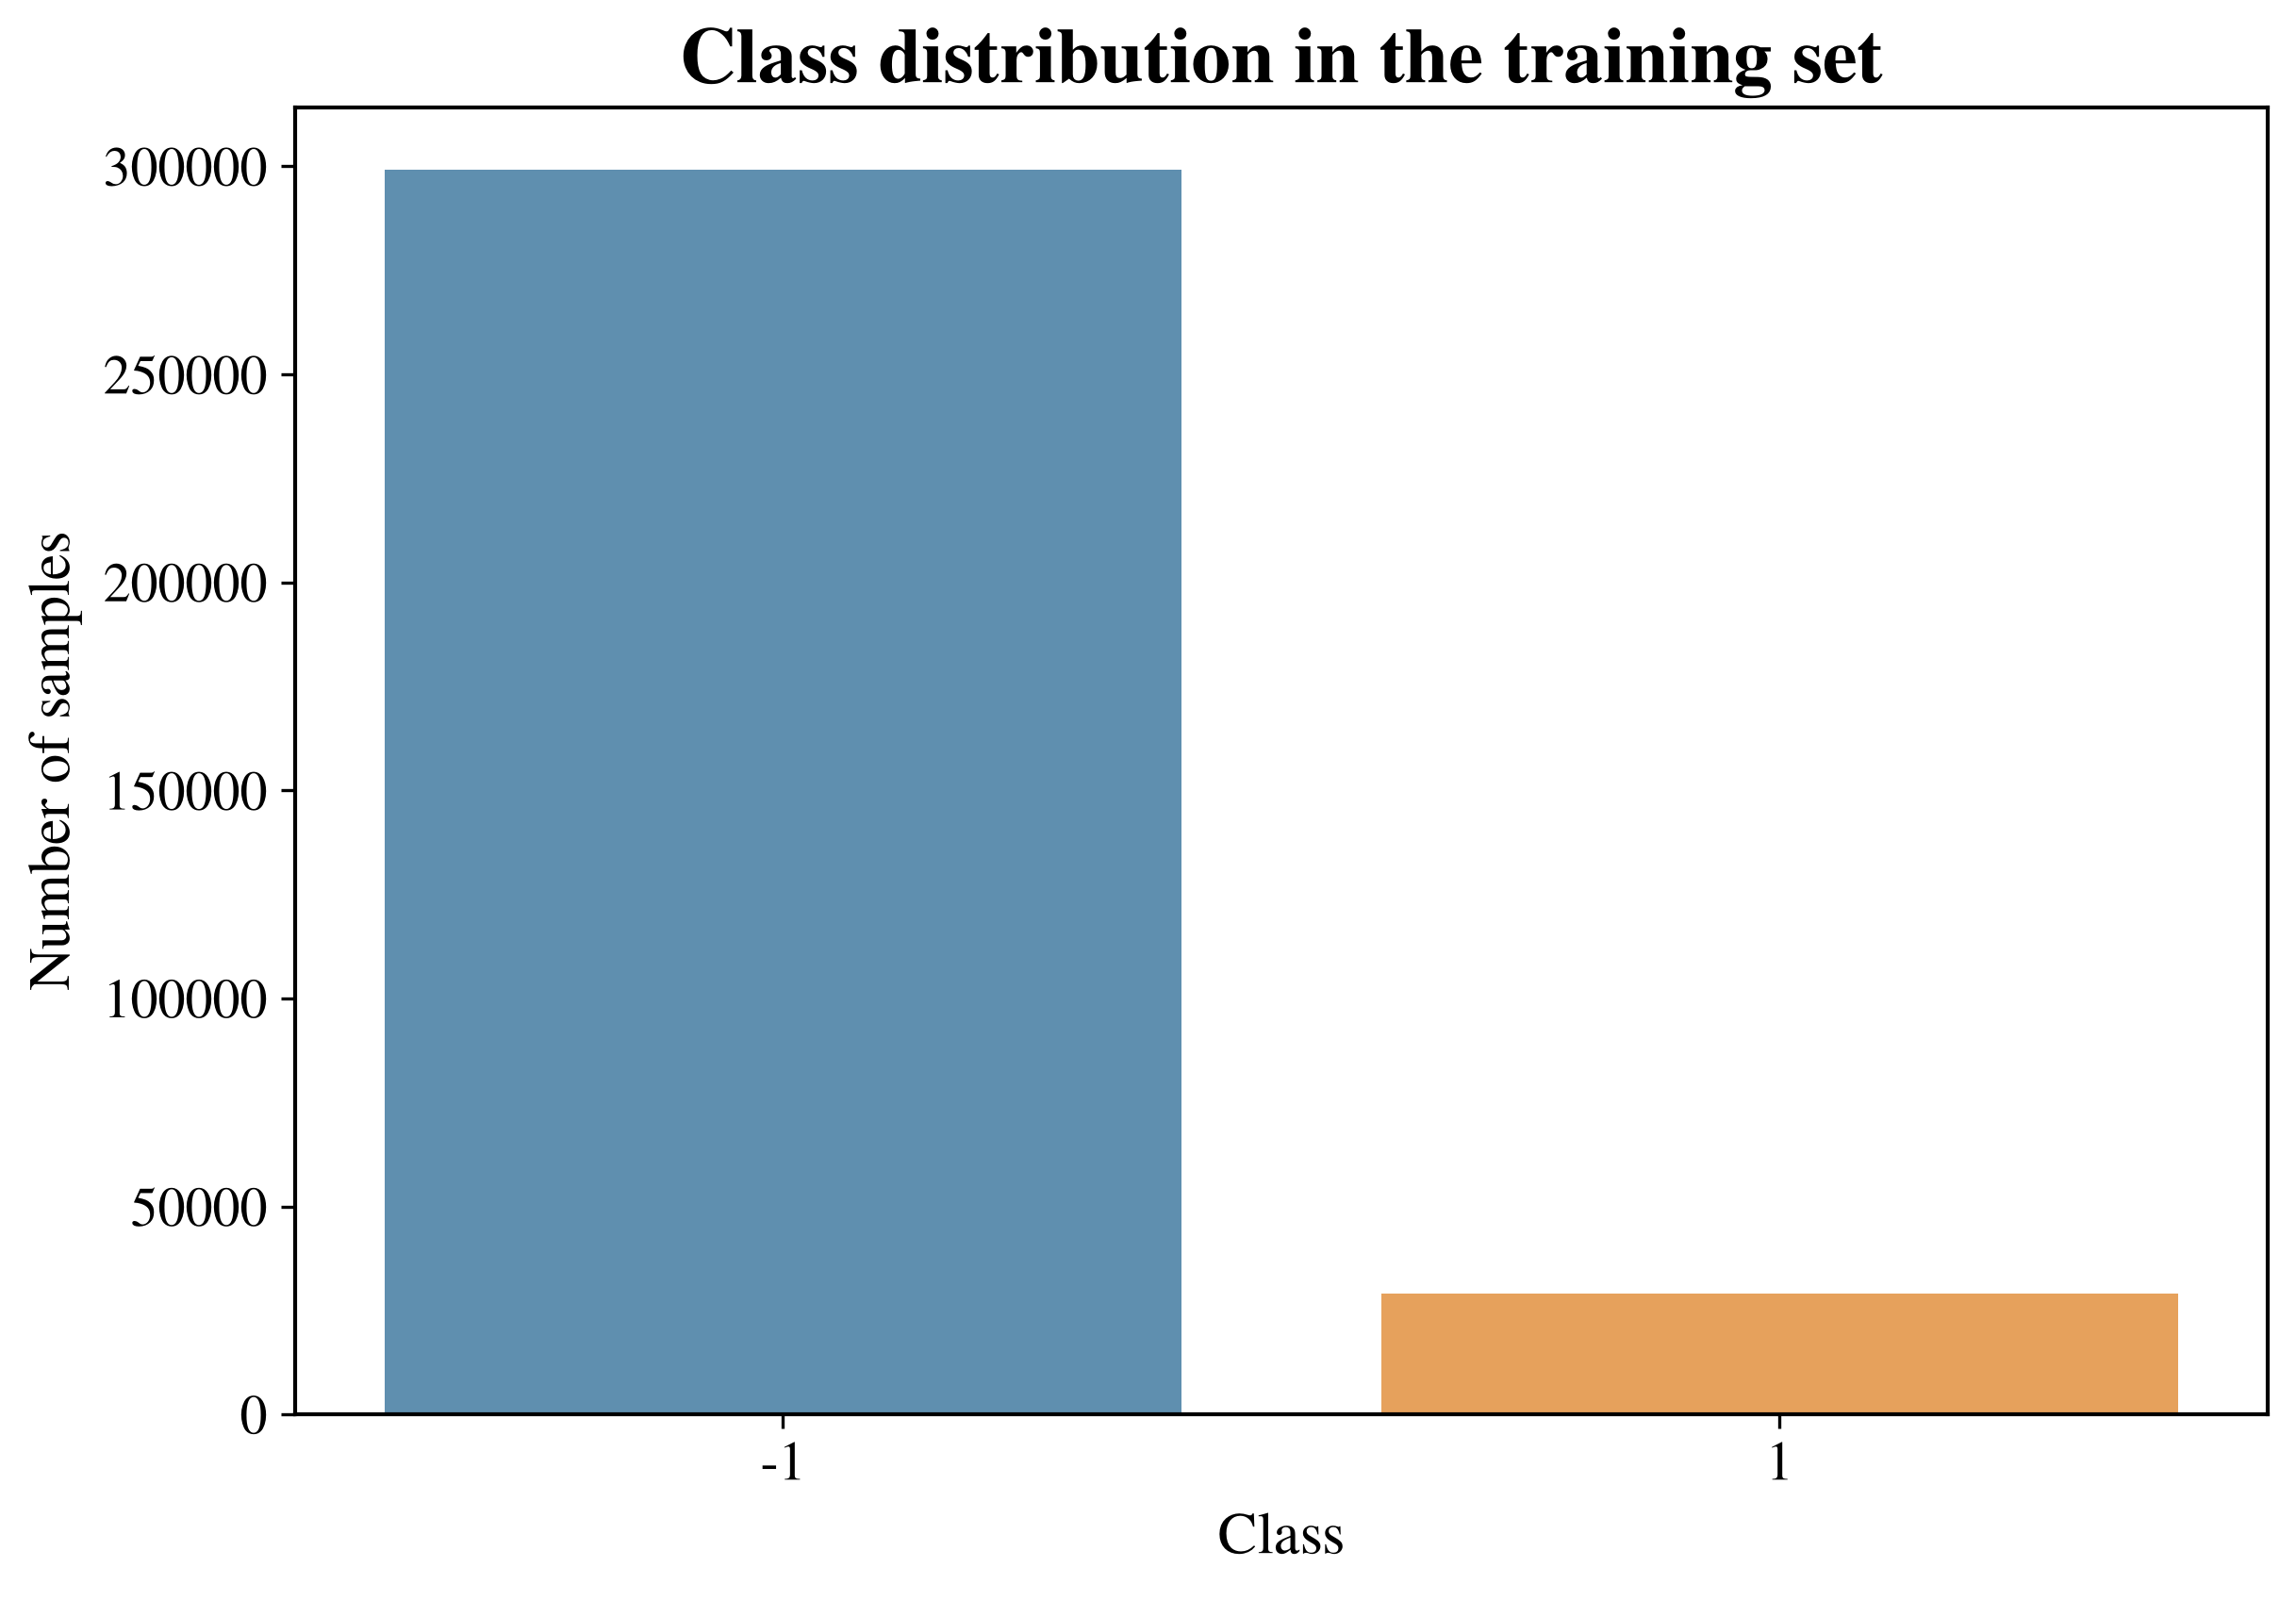

In [42]:
# Checking balance of the classes
unique, counts = np.unique(y_train, return_counts=True)

plt.bar(unique.astype(str), counts, color=[COLORS["blue"], COLORS["orange"]])
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Class distribution in the training set")
plt.grid(False)

plt.show()

In [43]:
print("NaNs in test features:", np.isnan(x_test_cleaned).sum())
print("NaNs in train features:", np.isnan(x_train_cleaned).sum())

NaNs in test features: 0
NaNs in train features: 0


---
### <center> Gradient Descent Vs Least Squares

First, we can compare the gradient descent algorithm to the ''true solution'' given by Least Squares, by iterating the different learnign parameters and seeing how it compares to the ''true loss''.

In [57]:
# grid testing for the learning rate (gamma) in gradient descent
#gammas = np.logspace(-5, 0, 15)
gammas = [0.01]
max_iters = 1000
initial_w = np.ones(x_train_cleaned.shape[1])
losses = []

for gamma in gammas:
    start_time = time.time()
    w, loss = imp.mean_squared_error_gd(y_train, x_train_cleaned, initial_w, 
                                        max_iters, gamma)
    end_time = time.time()
    print(f"Time taken for gamma {gamma:.5f}: {end_time - start_time:.2f} ", 
          "seconds")
    print(f"Loss for gamma {gamma:.5f}: {loss:.5f}")

    losses.append(loss)

# Least squares reference
w_ls, loss_ls = imp.least_squares(y_train, x_train_cleaned)

plt.semilogx(gammas, losses, marker="o", label="Gradient Descent", 
             color=COLORS["blue"])
plt.axhline(loss_ls, color=COLORS["red"], linestyle="--", label="Least Squares")
plt.xlabel("Learning rate (gamma)")
plt.ylabel("Loss")
plt.title("Loss vs Learning Rate for Gradient Descent")
plt.legend()
plt.show()

KeyboardInterrupt: 

We can look at how the number of iterations for a fixed gamma can affect the algorithm's loss (again, comparing to the least squares).

Testing max_iters: 100


/home/andras/Documents/MA3/Machine_learning/project1/code/implementations.py:28: RuntimeWarning: overflow encountered in square
  return 0.5 * np.mean(e**2)


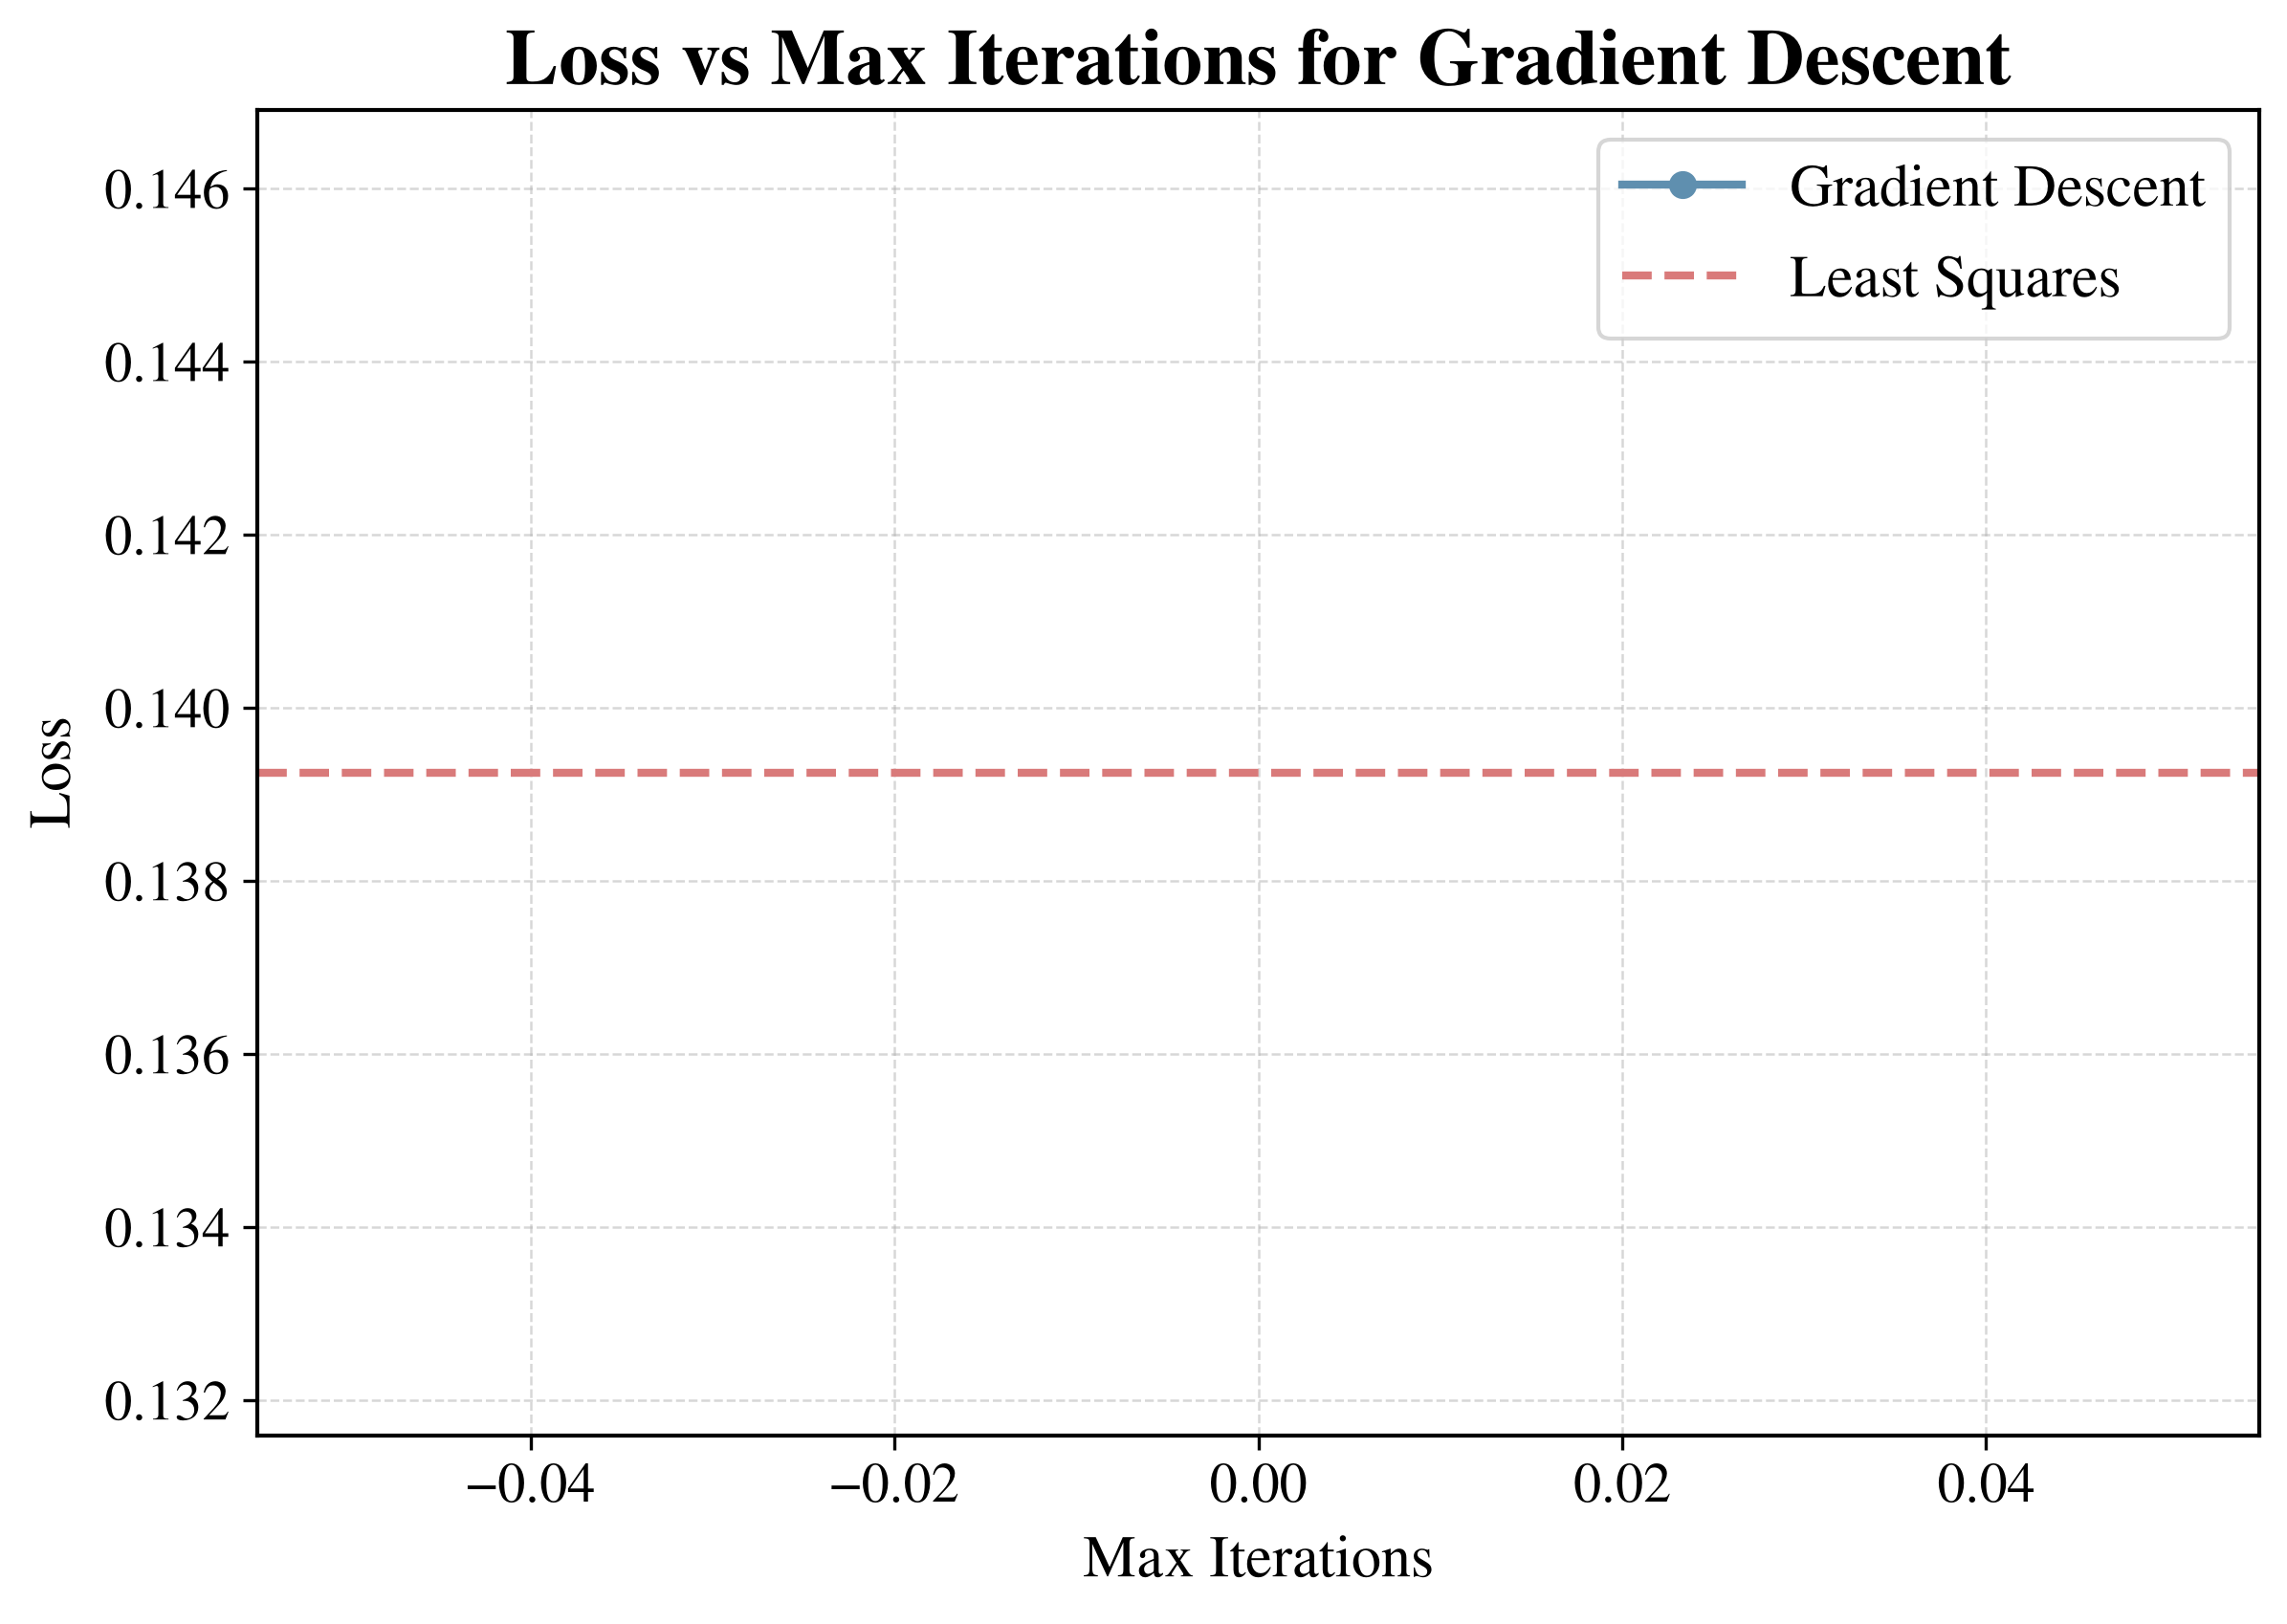

In [61]:
# grid testing max iterations for gradient descent
gamma = 0.000001
#max_iters_list = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000]
max_iters_list = [100]
gd_losses = []
initial_w = np.ones(x_train_cleaned.shape[1])

for max_iters in max_iters_list:
    print(f"Testing max_iters: {max_iters}")
    w_gd, loss_gd = imp.mean_squared_error_gd(y_train, x_train_cleaned, initial_w, 
                                              max_iters, gamma)
    gd_losses.append(loss_gd)

plt.plot(max_iters_list, gd_losses, marker="o", label="Gradient Descent", 
         color=COLORS["blue"])
plt.axhline(loss_ls, color=COLORS["red"], linestyle="--", label="Least Squares")
plt.xlabel("Max Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Max Iterations for Gradient Descent")
plt.legend()
plt.show()

In [62]:
print("Least squares loss:", loss_ls)
print("Gradient descent losses:", gd_losses)

Least squares loss: 0.13925336951992778
Gradient descent losses: [np.float64(inf)]


---
### <center> Stochastic Gradient Descent Vs Least Squares

---
### <center> Ridge Regression

---
### <center> Logistic Regression

In [ ]:
w, loss = imp.logistic_regression(y_train, x_train_cleaned, initial_w, max_iters, 0.00001)
print("Logistic regression loss:", loss)
print("Least squares loss:", loss_ls)

/home/andras/Documents/MA3/Machine_learning/project1/code/implementations.py:199: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-t))


Logistic regression loss: -28.439085438185327
Least squares loss: 0.13925336951992778


---
### <center> Regularised Logistic Regression